In [120]:
import sys
sys.path.append("../")

import numpy as np 
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

from scipy.signal import convolve, gaussian
from scipy.stats import pearsonr

from vi_rnn.saving import load_model
from vi_rnn.utils import *
from vi_rnn.load_data import * 

from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic
from scipy.special import binom
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

### Load the dataset

In [2]:
def activation_fn(U, z, B, activation):
    if activation == 'clipped_relu':
        return relu(U@z+B) - relu(U@z)
    return np.tanh(U@z)

def dyn_eq(x, U, V, W, B, tau, neuromodulation, activation='clipped_relu'):
        z = np.array([x])
        if neuromodulation == 'postsynaptic' and W is not None:
            R = activation_fn(U, z, B, activation) 
            R = R.reshape(-1, 1)
            print(R.shape)
            zn= (tau)*z + V@(W*R)
        elif neuromodulation == 'presynaptic' and W is not None:
            R = relu(W@U@z+B) - relu(W@U@z)
            zn=(tau)*z + V@R
        elif neuromodulation == 'additive': 
            R = relu(U@z+B + W)-relu(U@z + W)
            zn=(tau)*z+V@R
        elif neuromodulation == 'rank': 
            R = relu(U@z+B)-relu(U@z)
            zn=(tau)*z+W@V@R
        else:
            R = relu(U@z+B)-relu(U@z)
            zn=(tau)*z+V@R
        h=.1
        dz = (zn-z)/h
        return dz

## Define util functions

In [3]:
def plot_phase_portrait(model, s, z_list, neuromod_trace=None, neuromodulation=None, xlims=1, ylims=6, filename=None, activation='clipped_relu'):
    prior = model.rnn.transition
    U = model.rnn.transition.m.detach().numpy()
    V = model.rnn.transition.n.detach().numpy() 
    if hasattr(model.rnn.transition, 'A'):
        A = model.rnn.transition.A.detach().numpy() 
    else: A = None
    tau = prior.cast_A(prior.AW).detach().numpy().squeeze()
    B = prior.h.detach().numpy()
    N,R = U.shape
    I = np.eye(N)
    W = None 
    if A is not None and neuromodulation != 'additive' and neuromodulation != 'rank':
        W = np.eye(N) + np.diag(A @ s)
    elif neuromodulation == 'rank':
        W = np.eye(R) + np.diag(A @ s)
    elif A is not None: 
        W = A @ s 
    
    def activation_fn(U, z, B, activation):
        if activation == 'clipped_relu':
            return relu(U@z+B) - relu(U@z)
        return np.tanh(U@z)
  
    def dyn_eq(x,y):
        z = np.array([x,y])
        if neuromodulation == 'postsynaptic' and W is not None:
            R = activation_fn(U, z, B, activation) 
            zn=(tau)*z + V@W@R
        elif neuromodulation == 'presynaptic' and W is not None:
            R = relu(W@U@z+B) - relu(W@U@z)
            zn=(tau)*z + V@R
        elif neuromodulation == 'additive': 
            R = relu(U@z+B + W)-relu(U@z + W)
            zn=(tau)*z+V@R
        elif neuromodulation == 'rank': 
            R = relu(U@z+B)-relu(U@z)
            zn=(tau)*z+W@V@R
        else:
            R = relu(U@z+B)-relu(U@z)
            zn=(tau)*z+V@R
        h=.1
        dz = (zn-z)/h
        return dz[0],dz[1]
    
    
    X, Y = np.meshgrid(np.linspace(-xlims, xlims, 200), np.linspace(-ylims, ylims, 200))
    u, v = np.zeros_like(X), np.zeros_like(X)
    NI, NJ = X.shape
    c1 = 'orangered'
    c2 = 'dodgerblue'
    hw = .1
    v_norm = .2
    st_scale = .1
    norm = np.zeros((NI,NJ))
    for i in range(NI):
        for j in range(NJ):
            x, y = X[i, j], Y[i, j]
            dx, dy = dyn_eq(x,y)
            u[i,j] = dx
            v[i,j] = dy
            norm[i,j]=np.log(np.linalg.norm([dx,dy]))
    
    with mpl.rc_context(fname='matplotlibrc'):
    
        fig,ax = plt.subplots(figsize=(10,4),dpi=300)
    
        ax.imshow(norm,extent = [-xlims,xlims,-ylims,ylims], 
                origin ='lower',cmap ='Spectral',vmax=np.max(norm),aspect='auto')
        ax.streamplot(X, Y, u, v,color='white')
        ax.set_box_aspect(1)
        ax.spines[['right','top']].set_visible(False)
    
        ax.set_xlim(-xlims,xlims)
        ax.set_ylim(-ylims,ylims)
        ax.set_xticks([-xlims,0,xlims])
        ax.set_yticks([-ylims,0,ylims])
        ax.set_xlabel(r"$z_1$")
        ax.set_ylabel(r'$z_2$')
        for i, z in enumerate(z_list):
            e,v = np.linalg.eig(compute_jacobian(z, U,V,h,a,A, s, neuromodulation)) ##compute_jacobian(z_cur, U, V, h, a, A, np.array([s_vals[i]]), neuromodulation)
            for i in range(len(e)):
                # check if complex conjugate
                if np.iscomplex(e[i]):
                    ax.scatter(z[0],z[1],color='mediumvioletred',zorder=1000,marker="*")
                else:
                    ax.scatter(z[0],z[1],color='black',zorder=1000)
    
                    if abs(e[i])>1:
                        ax.arrow(z[0],z[1],v[0,i]*v_norm,v[1,i]*v_norm,head_width=hw,color=c1,zorder =1000)
                        # opposite arrow
                        ax.arrow(z[0],z[1],-v[0,i]*v_norm,-v[1,i]*v_norm,head_width=hw,color=c1,zorder=1000)
                    else:
                        ax.arrow(z[0]+v[0,i]*v_norm,z[1]+v[1,i]*v_norm,-v[0,i]*v_norm*st_scale,-v[1,i]*v_norm*st_scale,head_width=hw,color=c2,zorder=1200)
                        # opposite arrow
                        ax.arrow(z[0]-v[0,i]*v_norm,z[1]-v[1,i]*v_norm,v[0,i]*v_norm*st_scale,v[1,i]*v_norm*st_scale,head_width=hw,color=c2,zorder=1200)
    # ax.set_title(f's={s[0]:.2f}')
    # ax.plot(Z[0, :], Z[1, :])
    if filename is not None:
        fig.savefig(filename, format='svg')

### Load and preprocess data

### Load NK341

In [81]:
config = {
    'data_dir': '../data/recordings/nk341_mPFC/', 
    'dales_law': True,
    'out_dir': "../models/dtt/",
    'sampling_rate': 30_000,
    'bin_size': 0.05,
    'fr_threshold': 0.5,
    'threshold_neurons': True,
    'z_score_neuromod': False,
    'min_max_norm_neuromod': True,
    'z_score_neurons': False,
    'deconvolve': False,
    'convolve_spikes': True,
    'normalize_neuromod': True,
    'center_neuromod': False,
    'load_physiology': False,
    'shuffle': False
}

### Load dataset

In [82]:
spikes, spike_counts, neuromod_activity, trials_df, cell_types = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_test_end'] = int(data_dur - 0.75 * baseline_dur) 

config['baseline_train_start'] = config['baseline_test_end'] 
config['baseline_train_end'] = int(data_dur) 

# prepare dataset 
x_test, s_test, stim_arr_test, seq_periods, _, _, _ = prepare_dataset(spike_counts, 
                                                                        neuromod_activity,
                                                                        trials_df, 
                                                                        config,
                                                                        test=True)
# load training s samples for normalization 
_, s_train, _, _, _, _, _ = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=False)
s_min, s_max = s_train.min(), s_train.max() 
s_test = (s_test - s_train.min()) / (s_train.max() - s_train.min())

# convert to torch tensors 
x_test = torch.from_numpy(x_test).to(torch.float32) 
s_test = torch.from_numpy(s_test).to(torch.float32)
stim_arr_test = torch.from_numpy(stim_arr_test).to(torch.float32) 

t_end = 7869
84 neurons removed
cell type: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1 -1  1  1  1  1 -1  1  1
  1  1  1 -1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1  1
  1  1  1]
length of downsampled signal: 157771
length of original signal: 7888521
False
False
(17080,) (31270,)
Shape of data samples: (147, 31270), (31270,)
(51300,) (69790,)
Shape of data samples: (147, 69790), (69790,)


In [91]:
model, params, task_params, training_params = load_model('../models/all/nk341_mPFC_None_rank_2_activation_clipped_relu_seed_0_stim_True_binsize_0_05_daleslaw_False')

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'cell_types', 'rnn_architecture'])
147 147
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 4
147


/network/iss/karalis/users/kaleab.belay/mnm/generate_figures/../vi_rnn/saving.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b)

In [92]:
# Extract parameters 
a, V, U, B, I = get_loadings(model)
A = None
# A = model.rnn.transition.A.detach().numpy()
hz = model.rnn.transition.hz.detach().numpy()
h = model.rnn.transition.h.detach().numpy()
W_inp = model.rnn.transition.Wu.detach().numpy()
R, N = V.shape

In [93]:
# Orthogonalize
U, S, V = np.linalg.svd(U @ V)
U = U[:, :R]
V = (V[:R].T*S[:R]).T

### Find the fixed points of the network

In [94]:
# Test conversion function
# This should print numbers close to 0!

V_new, U_new, h_new = convert_clipped(V.T,U,h)
# use orthogonalized low-rank matrices ``
model.rnn.transition.m = torch.nn.Parameter(torch.from_numpy(U))
model.rnn.transition.n = torch.nn.Parameter(torch.from_numpy(V))
# test_conversion(V, V_new, U, U_new, h, h_new, N, R, 0.1)


In [87]:
s = np.array([0.111])
inp = np.zeros((9,))
# inp[4] = 1.0
D_list,D_inds,z_list, n_singular = find_fixed_points_analytic(np.array([a, a,]), V_new.T, U_new, hz, h_new, d=2, neuromodulation=None, A=None, s=s, Wu=W_inp, u=inp)

Intersection indices shape: (43071, 2)
43071
removed parallel lines
42924
4


  0%|          | 0/42924 [00:00<?, ?it/s]

100%|██████████| 42924/42924 [00:01<00:00, 33550.84it/s]


(171696, 294)
(43513, 294)
Found a fixed point
[ 0.98594355 -0.99363886]
Found a fixed point
[ 0.54756909 -0.61347719]
Found a fixed point
[-0.14051202  0.71547388]
Done, found 3 fixed points


In [88]:
for i in range(len(z_list)):
    J = compute_jacobian(z_list[i], U, V, h, a, A=None, s=s)
    e,v = np.linalg.eig(J)
    print(abs(e) > 1)
    print(e)

[False False]
[0.879098+0.06581448j 0.879098-0.06581448j]
[ True False]
[1.27839533 0.79910657]
[False False]
[0.86072572+0.09213196j 0.86072572-0.09213196j]


### Plot vector field

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

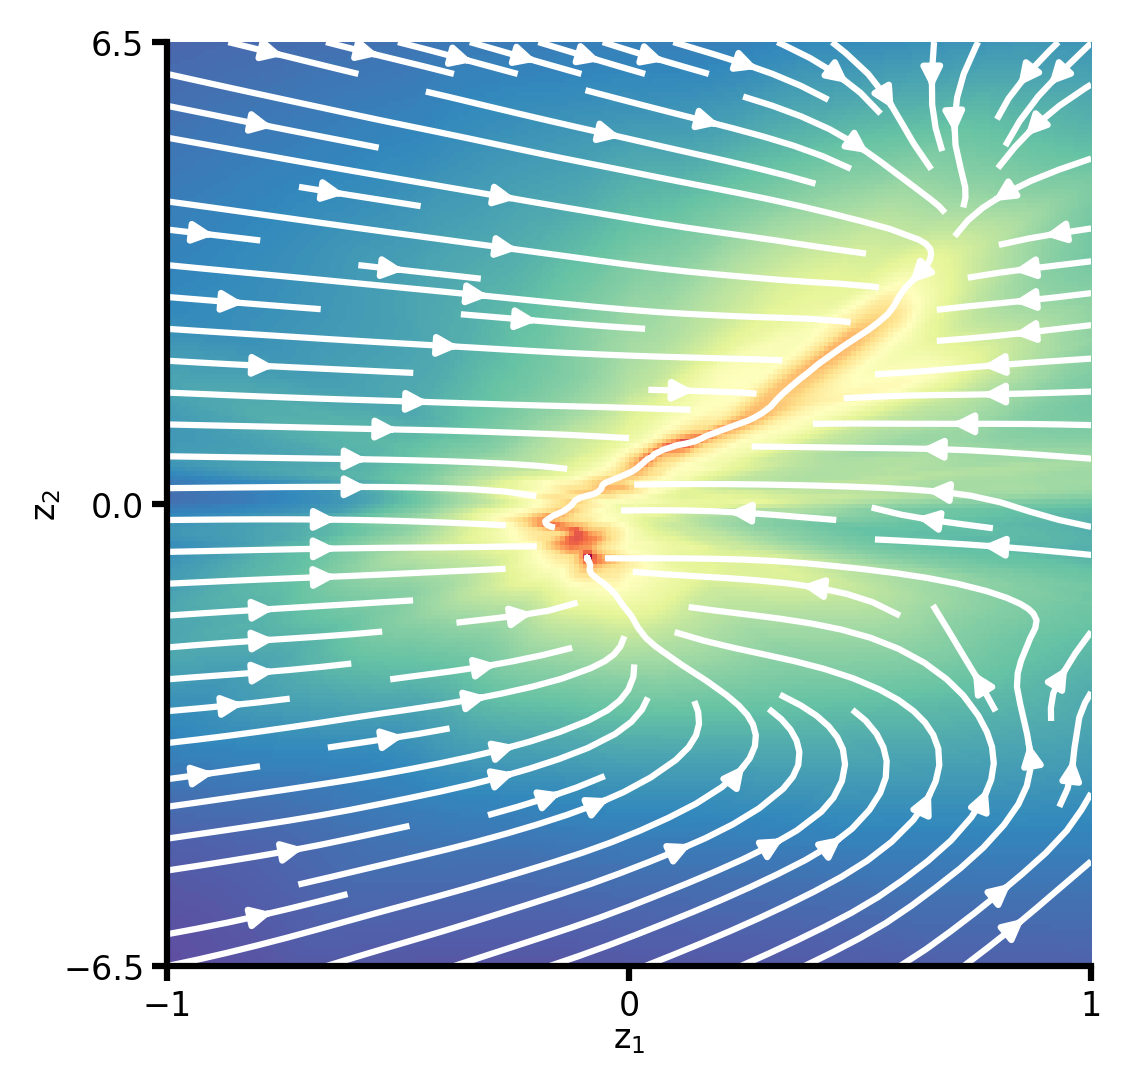

In [96]:
plot_phase_portrait(model, np.array([0.9]), [], neuromodulation=None, xlims=1, ylims=6.5, filename=None)


### Generate trajectory during baseline conditions

In [97]:
x_baseline = x_test[:, seq_periods[0][0]:seq_periods[0][1]]
s_baseline = s_test_nk339[seq_periods[0][0]:seq_periods[0][1]]
stim_arr_baseline = stim_arr_test[:, seq_periods[0][0]: seq_periods[0][1]]

Z, obs = generate_trajectory(x_baseline, s_baseline, stim_arr_baseline, model, None)

Text(0, 0.5, '${z_2}$')

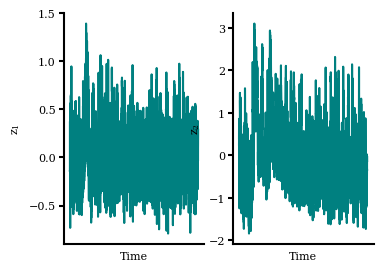

In [98]:
fig, ax = plt.subplots(1, 2, figsize=(4,3))
Z = Z.reshape(2, -1)
Z0, Z1 = Z[0, :], Z[1, :]
ax[0].plot(Z0, c='teal')
ax[0].set_xticks([])
ax[0].set_xlabel('Time', labelpad=5)
ax[0].set_ylabel(r'${z_1}$', labelpad=5)

ax[1].plot(Z1, c='teal')
ax[1].set_xlabel('Time', labelpad=5)
ax[1].set_xticks([])
ax[1].set_ylabel(r'${z_2}$', labelpad=5)
# fig.savefig('../../results/figures/z1_none.png')

In [20]:
# X = x_baseline
# m_inv = torch.linalg.pinv(model.rnn.transition.m)
# z_proj = (m_inv @ X).detach()
# v = z_list[2] - z_list[0]
# subtract z0 from all z so that all vectors have the same origin
# z_proj = z_proj - z_list[0].reshape(-1, 1)
# v_norm = np.dot(v, v) 
# alpha =  (z_proj.T @ v) / (v_norm)

In [21]:
# z_proj_gen = Z - z_list[0].reshape(-1, 1)
# alpha_gen = (z_proj_gen.T @ v) / (v_norm)

In [22]:
# m_inv = torch.linalg.pinv(model.rnn.transition.m)
# z_proj = (m_inv @ X).detach()

In [99]:
# fig, ax = plt.subplots(figsize=(4,3))
# ax.plot(z_proj[0, :], c='teal')
# ax.set_xticks([])
# ax.set_xlabel('Time', labelpad=5)
# ax.set_ylabel(r'${z_1}$', labelpad=5)
# fig.savefig('../../results/figures/z1_none.png')

In [100]:
# fig, ax = plt.subplots(figsize=(4,3))
# ax.plot(z_proj[1, :], c='teal')
# ax.set_xticks([])
# ax.set_xlabel('Time', labelpad=5)
# ax.set_ylabel(r'${z_2}$', labelpad=5)
# fig.savefig('../../results/figures/z2_none.png')

In [101]:
# fig, ax = plt.subplots(figsize=(4,3))
# ax.plot(s_baseline, c='teal')
# ax.set_xticks([])
# ax.set_xlabel('Time', labelpad=5)
# ax.set_ylabel('s', labelpad=5)
# fig.savefig('../../results/figures/s_baseline.png')

0.5822900684828729


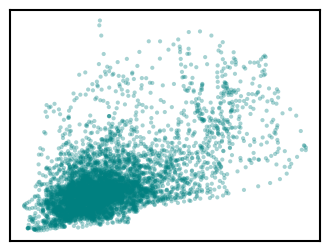

In [26]:
# from scipy.stats import pearsonr 

# fig, ax = plt.subplots(figsize=(4,3))
# corr = pearsonr(alpha, s_baseline[:len(alpha)])[0]
# print(corr)
# ax.scatter(alpha, s_baseline[:len(alpha)], c='teal', alpha=0.35,edgecolors='none')
# ax.set_xticks([])
# ax.set_yticks([])
#ax.set_xlabel(r'$\alpha$', labelpad=5)
#ax.set_ylabel('s', labelpad=5)
# plt.title(f'R = {corr}')

# for spine in ax.spines.values():
    # spine.set_visible(True)

# fig.savefig('../../results/figures/alpha_s_plot.png')

### Dynamics of the Postsynaptically modulated model

In [102]:
model_config = {
    "dataset": "nk341_mPFC",
    "neuromodulation": "postsynaptic",
    "rank": 3, 
    "seed": 0
}
model, params, task_params, training_params = load_model(f'../models/all/{model_config["dataset"]}_{model_config["neuromodulation"]}_rank_{model_config["rank"]}_activation_clipped_relu_seed_{model_config["seed"]}_stim_True_binsize_0_05_daleslaw_False')
# Extract parameters 
a, V, U, B, I = get_loadings(model)                         
print(a)
A = model.rnn.transition.A.detach().numpy()
hz = model.rnn.transition.hz.detach().numpy()
h = model.rnn.transition.h.detach().numpy()
W_inp = model.rnn.transition.Wu.detach().numpy()
R, N = V.shape

# Orthogonalize
U, S, V = np.linalg.svd(U @ V)
U = U[:, :R]
V = (V[:R].T*S[:R]).T

# use orthogonalized low-rank matrices 
model.rnn.transition.m = torch.nn.Parameter(torch.from_numpy(U))
model.rnn.transition.n = torch.nn.Parameter(torch.from_numpy(V))

V_new, U_new, h_new = convert_clipped(V.T,U,h)
# test_conversion(V, V_new, U, U_new, h, h_new, N, R, s)

# s_vals, fixed_points = fixed_point_sweep(V_new, U_new, hz, h_new, a, A, W_inp, neuromodulation='postsynaptic', start=0.00, end=1.0, num_points=100)


dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'cell_types', 'rnn_architecture'])
147 147
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
147
0.9179969


/network/iss/karalis/users/kaleab.belay/mnm/generate_figures/../vi_rnn/saving.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b)

In [103]:
# load s_vals and fixed_points arrays 
with open(f'../results/pickle/{model_config["neuromodulation"]}_rank_{model_config["rank"]}_s_vals_{model_config["dataset"]}_seed_{model_config["seed"]}_bifurcation.pkl', 'rb') as f: 
    s_vals = pickle.load(f)
with open(f'../results/pickle/{model_config["neuromodulation"]}_rank_{model_config["rank"]}_fixed_points_{model_config["dataset"]}_seed_{model_config["seed"]}_bifurcation.pkl', 'rb') as f: 
    fixed_points = pickle.load(f) 

In [104]:
def compute_jacobian(z, U, V, hz, a, A, s, neuromodulation=None):
    N,R = U.shape
    I = np.eye(N)

    if A is not None and neuromodulation == 'rank':
        W = np.eye(R) + np.diag(A @ s) 
    elif A is not None and neuromodulation != 'additive':
        W = I + np.diag(A @ s)
    elif A is not None: 
        W = A @ s
        
    if A is not None and neuromodulation == 'postsynaptic':
        x = U @ z
        phi_drv = np.diag(relu_derivative(x + hz)) - np.diag(relu_derivative(x))
        W = I + np.diag(A @ s)
        J = a * np.eye(R) + V @ W @ phi_drv @ U
        
    elif A is not None and neuromodulation == 'presynaptic':
        W = I + np.diag(A @ s) 
        print(W.shape, U.shape, z.shape)
        x = W @ U @ z
        phi_drv = np.diag(relu_derivative(x + hz)) - np.diag(relu_derivative(x))
        J = a * np.eye(R) + V @ W @ phi_drv @ U

    elif A is not None and neuromodulation == 'rank': 
        W = np.eye(R) + np.diag(A @ s) 
        x = U @ z 
        phi_drv = np.diag(relu_derivative(x + hz)) - np.diag(relu_derivative(x))
        J = a * np.eye(R) + W @ V @ phi_drv @ U
    
    else:
        x = U @ z
        phi_drv = np.diag(relu_derivative(x + hz)) - np.diag(relu_derivative(x))
        J = a * np.eye(R) + V @ phi_drv @ U
        
    return J 

def classify_fixed_points(U, V, h, a, A, s_vals, neuromodulation, fixed_points):
    stable = []
    unstable = []
    eig_vals = []
    for i in range(len(s_vals)):
        eig_vals_s = []
        for j in range(len(fixed_points[i])):
            # compute the stability of each fixed point 
            z_cur = fixed_points[i][j]
            # print(z_cur) 
            # input(':')
            J = compute_jacobian(z_cur, U, V, h, a, A, np.array([s_vals[i]]), neuromodulation) 
            e, v = np.linalg.eig(J)
            if (e < 1.0).all():
                stable.append([z_cur[k] for k in range(U.shape[1])] + [s_vals[i]])
  
            else:
                unstable.append([z_cur[k] for k in range(U.shape[1])] + [s_vals[i]])
            eig_vals_s.append(e - 1.0)
        eig_vals.append(eig_vals_s)  
    return stable, unstable, eig_vals

stable, unstable, eig_vals = classify_fixed_points(U, V, h, a, A, s_vals, neuromodulation=model_config["neuromodulation"], fixed_points=fixed_points)

Text(0.5, 1.0, 'Bifurcation Diagram')

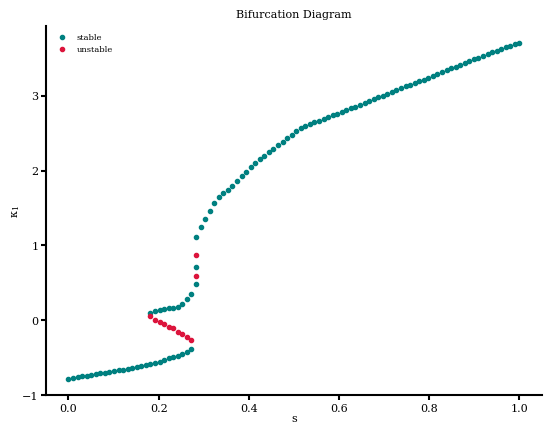

In [105]:
fig, ax = plt.subplots()
stable = np.array(stable)
unstable = np.array(unstable)

ax.scatter(stable[:, 3], stable[:, 2], label='stable', c='teal')
ax.scatter(unstable[:, 3], unstable[:, 2], label='unstable', c='crimson')

# ax.scatter(stable[:, 2], stable[:, 0], label='stable', c='teal')
# ax.scatter(unstable[:, 2], unstable[:, 0], label='unstable', c='crimson')

ax.set_xlabel('s')
ax.set_ylabel(r'$\kappa_1$')
# ax.set_xticks(np.arange(0, 1, 0.1))
# ax.set_xticklabels(f'{s_vals[i]:.2f}' for i in range(0, len(s_vals), 15)) 
# ax.axvline(s_test_baseline.mean(), linestyle='--', alpha=0.5)
# ax.axvline(s_test_baseline.mean() + s_test_baseline.std(), linestyle='--', alpha=0.5)
ymin, ymax = ax.get_ylim()
# ax.text(s_test_baseline.mean(), ymax * 0.9, 'Baseline Mean', rotation=90, color='black', va='top', ha='right')
# ax.text(s_test_baseline.mean() + s_test_baseline.std(), ymax * 0.9, '1 stdev', rotation=90, color='black', va='top', ha='right')
# ax.set_xticks([0, np.round(s_test_baseline.mean(), 1), s_test_baseline.mean() + s_test_baseline.std(), 0.25])
ax.legend()
# ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# ax.set_xlim([0, 0.5])
plt.title('Bifurcation Diagram')
# # fig.savefig('../../results/figures/nk339_bifurcations_postsynaptic_1.svg', format='svg')

### Generate Trajectory

In [106]:
x_test_baseline = x_test[:, seq_periods[0][0]: seq_periods[0][1]]
s_test_baseline = s_test[seq_periods[0][0]: seq_periods[0][1]]
stim_arr_test_baseline = stim_arr_test[:, seq_periods[0][0]: seq_periods[0][1]]

t_start, t_end = config['baseline_test_start'], config['baseline_test_end'] - 1
spike_counts_baseline, neuromod_baseline = get_block(spike_counts, neuromod_activity, t_start, t_end, config['bin_size'])

# spike_counts_baseline, neuromod_baseline, whisking_baseline, pupil_area_baseline = get_block(spike_counts, neuromod_activity, t_start, t_end, config['bin_size'], whisking=whisking, pupil_area=pupil_area)
# no stimuli for now 
stim = torch.zeros((9, spike_counts_baseline.shape[1]))
Z, trajs = generate_trajectory(x_test_baseline, s_test_baseline, stim_arr_test_baseline, model, 'additive')
Z = Z.reshape(R, -1)

Text(0.5, 0.01, 'Time')

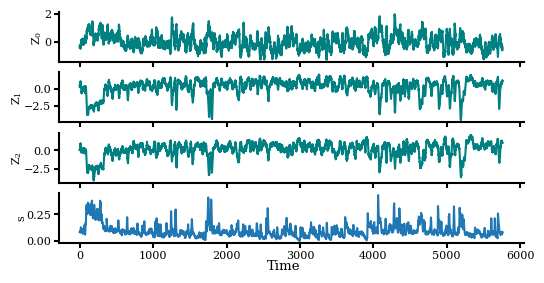

In [34]:
fig, ax = plt.subplots(4,1, figsize=(6,3), sharex=True)
ax[0].plot(Z[0], c='teal')
ax[0].set_ylabel(rf'$Z_{{{0}}}$')

ax[1].plot(Z[1], c='teal')
ax[1].set_ylabel(rf'$Z_{{{1}}}$')

ax[2].plot(Z[2], c='teal')
ax[2].set_ylabel(rf'$Z_{{{2}}}$')

ax[3].plot(s_test_baseline)
ax[3].set_ylabel(rf's')

# ax.set_xticks([])
fig.supxlabel('Time')

# fig.savefig('../../results/figures/z1_none.png')

#### Plot time constant of fixed points for different values of s

Text(0, 0.5, '$\\tau$')

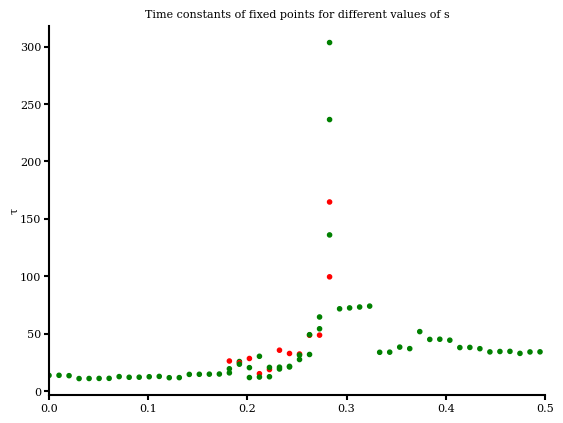

In [107]:
time_constants = []
s_vals_plot = []
colors = []
for i in range(len(eig_vals)):
    for j in range(len(eig_vals[i])):
        if eig_vals[i][j].max() > 0: colors.append('red')
        else: colors.append('green')
        time_constants.append(1 / np.abs(np.real(eig_vals[i][j])).min())
        s_vals_plot.append(s_vals[i])
plt.scatter(s_vals_plot, time_constants, c=colors)
plt.xlim([0, 0.5])
plt.title('Time constants of fixed points for different values of s')
plt.ylabel(r'$\tau$')

### Compute the sensitivity of the system for different values of s to investigate criticality

In [108]:
s = s_test[seq_periods[0][0]:seq_periods[0][1]]
# Initialize the latents at the fixed points and generate a trajectory with perturbations, keeping s constant
# compute the averaged max amplitude difference from the fixed point 
T = 50
z0_delta_mean, z1_delta_mean = [], []
z0_delta_std, z1_delta_std = [], [] 

num_trajs = 20
# trajs = []
for fp, s_fp in zip(fixed_points, s_vals):
    z0_delta_arr, z1_delta_arr = [], []
    z0 = torch.tensor(fp).to(torch.float32)
    s_fxd = torch.full((T,), s_fp).to(torch.float32)
    
    for i in range(num_trajs):
        # generate a trajectory 1, 
        Z_new = model.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=None, s=s_fxd.view(1, 1, -1).to(torch.float32), noise_scale=0.25, sim_v=False, sim_s = False)
        Z_new = Z_new.reshape((R,-1))
        z0_delta_arr.append(np.abs(Z_new[0] - z0[0, 0]).max())
        z1_delta_arr.append(np.abs(Z_new[1] - z0[0, 1]).max())
        # trajs.append(Z_new)
        
    z0_delta_mean.append(np.array(z0_delta_arr).mean())
    z0_delta_std.append(np.array(z0_delta_arr).std()) 
    
    z1_delta_mean.append(np.array(z1_delta_arr).mean())
    z1_delta_std.append(np.array(z1_delta_arr).std())

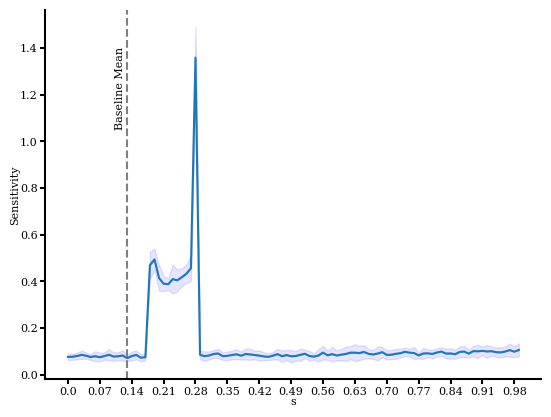

In [109]:
fig, ax = plt.subplots()
ax.plot(z0_delta_mean)
ax.fill_between(np.arange(0, len(z0_delta_mean)), z0_delta_mean, np.array(z0_delta_mean) - np.array(z0_delta_std), alpha=0.1, color='blue')
ax.fill_between(np.arange(0, len(z0_delta_mean)), z0_delta_mean, np.array(z0_delta_mean) + np.array(z0_delta_std), alpha=0.1, color='blue')

ax.set_xticks(np.arange(0, len(z0_delta_mean), 7))
ax.set_xticklabels(str(i)[:4] for i in s_vals[::7])
# ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlabel('s')
ax.set_ylabel('Sensitivity')

ymin, ymax = ax.get_ylim()
ax.axvline(x=np.searchsorted(s_vals, s_test.mean())-1, color='gray', linestyle='--', label='Mean Test s')
ax.text(np.searchsorted(s_vals, s_test.mean()) - 1.5, ymax * 0.9, 'Baseline Mean', rotation=90, color='black', va='top', ha='right')

plt.show()
# plt.savefig('../results/figures/sensitivity_to_perturbations.png')

### Compute the variance of neural activity for different values of s

In [110]:
z1_variance_means, z1_variance_stderrs = [], []
z2_variance_means, z2_variance_stderrs = [], []

num_trajs = 10
for fp, s_fp in zip(fixed_points, s_vals):
    z0 = torch.tensor(fp).to(torch.float32)
    s_fxd = torch.full((T,), s_fp).to(torch.float32)
    var_z1, var_z2 = [], []
    
    for i in range(num_trajs):
        # generate a trajectory 
        Z_new = model.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=None, s=s_fxd.view(1, 1, -1).to(torch.float32), noise_scale=0.25, sim_v=False, sim_s = False)
        Z_new = Z_new.reshape((R,-1))    
        var_z1.append(Z_new[0].std() ** 2)
        var_z2.append(Z_new[1].std() ** 2) 
    # if s_fp > 0.15: break
    z1_variance_means.append(np.array(var_z1).mean())
    z2_variance_means.append(np.array(var_z2).mean())
    
    z1_variance_stderrs.append(np.array(var_z1).std() / np.sqrt(len(var_z1)))
    z2_variance_stderrs.append(np.array(var_z2).std() / np.sqrt(len(var_z2)))

Text(0.5, 1.0, 'Variance')

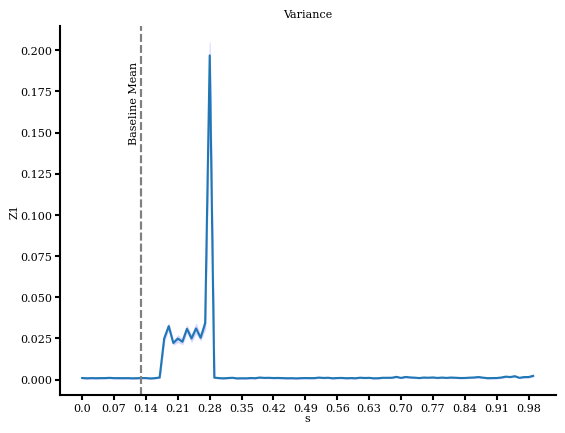

In [111]:
fig, ax = plt.subplots()
ax.plot(z1_variance_means)
ax.fill_between(np.arange(0, len(z1_variance_means)), z1_variance_means, np.array(z1_variance_means) - np.array(z1_variance_stderrs), alpha=0.1, color='blue')
ax.fill_between(np.arange(0, len(z1_variance_means)), z1_variance_means, np.array(z1_variance_means) + np.array(z1_variance_stderrs), alpha=0.1, color='blue')
ymin, ymax = ax.get_ylim()
ax.axvline(x=np.searchsorted(s_vals, s_test.mean())-1, color='gray', linestyle='--', label='Mean Test s')
ax.set_xticks(np.arange(0, len(z1_variance_means), 7))
ax.set_xticklabels(str(i)[:4] for i in s_vals[::7])
# ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlabel('s')
ax.set_ylabel('Sensitivity')
ax.set_ylabel('Z1')
ax.set_xlabel('s')
ax.axvline(x=np.searchsorted(s_vals, s_test.mean())-1, color='gray', linestyle='--', label='Mean Test s')
ax.text(np.searchsorted(s_vals, s_test.mean()) - 1.5, ymax * 0.9, 'Baseline Mean', rotation=90, color='black', va='top', ha='right')
ax.set_title('Variance')
# fig.savefig('../results/figures/variance_criticality.png')

### Compute sliding window correlation

In [141]:
from scipy.stats import pearsonr 

# use entire baseline period
t_start = config['baseline_test_start']
t_end = config['baseline_train_end']

x, neuromod = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size']) 
s = (neuromod - s_min) / (s_max - s_min) 
# s = (neuromod - neuromod.mean()) / (neuromod.std())
x = x[:, :len(s)]
whisking = whisking[:len(s)]
pupil_area = pupil_area[:len(s)]

# generate a long trajectory from the model for baseline 
stim = torch.zeros((9, s.shape[0]))
Z, S, trajs = generate_trajectory(
    torch.from_numpy(x).to(torch.float32), 
    torch.from_numpy(s).to(torch.float32), 
    stim, 
    model, 
    model_config["neuromodulation"],
    sim_s=True)

Z = Z.reshape(R, -1)

# generate trajectories for the trial periods 
Z_trials, trajs_trials, s_trials, x_trials = [], [], [], []
for i in range(1, len(seq_periods)):
    Z_trial, _, traj_trial = generate_trajectory(
                x_test[:, seq_periods[i][0]:seq_periods[i][1]],
                s_test[seq_periods[i][0]:seq_periods[i][1]],
                stim_arr_test[:, seq_periods[i][0]:seq_periods[i][1]],
                model, 
                model_config["neuromodulation"],
                sim_s=True,
            )
    Z_trials.append(Z_trial.reshape(R,-1))
    trajs_trials.append(traj_trial)
    s_trials.append(s_test[seq_periods[i][0]:seq_periods[i][1]])

for i in range(1, len(seq_periods_train)):
    x_trial = torch.from_numpy(x_train[:, seq_periods_train[i][0]:seq_periods_train[i][1]]).to(torch.float32)
    s_trial = torch.from_numpy(s_train[seq_periods_train[i][0]:seq_periods_train[i][1]]).to(torch.float32)
    s_trial = (s_trial - s_min) / (s_max - s_min)
    Z_trial, _, traj_trial = generate_trajectory(
                x_trial,
                s_trial,
                torch.from_numpy(stim_arr_train[:, seq_periods_train[i][0]:seq_periods_train[i][1]]).to(torch.float32),
                model, 
                model_config["neuromodulation"],
                sim_s=True
            )
    Z_trials.append(Z_trial.reshape(R,-1))
    trajs_trials.append(traj_trial)
    s_trials.append(s_train[seq_periods_train[i][0]:seq_periods_train[i][1]])


In [129]:
def sliding_window_correlation(seq, s, bin_width=20):
    i = 30
    min_overlap = bin_width - int(0.8 * bin_width)
    cor_values, s_means, best_lags = [], [], []
    var_values = []
    while i + bin_width < len(s): 
        s_bin = s[i: i + bin_width]
        j_start, j_end = i - min_overlap, i + bin_width - min_overlap
        
        best_corr_bin, best_lag, var_bin = 0, None, None
        while j_start < i + min_overlap:
            # print(j_start, j_end)
            try:
                r_bin = pearsonr(s_bin, seq[j_start:j_end])[0]
            except:
                print(j_start, j_end)
                break 
            # print(r_bin)
            if r_bin > best_corr_bin: 
                best_corr_bin = r_bin  
                best_lag = j_start - i
                var_bin = seq[j_start:j_end].std() ** 2
            j_start += 1 
            j_end += 1
        # print(var_bin)
        # input(':')
        var_values.append(var_bin)
        cor_values.append(best_corr_bin)
        best_lags.append(best_lag)
        s_means.append(np.median(s_bin)) 
        i += bin_width // 2 
    return cor_values, var_values, s_means, best_lags

In [142]:
cor_values_z1, var_values_z1, s_means_z1, best_lags_z1 = sliding_window_correlation(Z[0], s)
cor_values_z2, var_values_z2, _, best_lags_z2 = sliding_window_correlation(Z[1], s)
cor_values_z3, var_values_z3, _, best_lags_z3 = sliding_window_correlation(Z[2], s)

# repeat for trial conditions 
for i in range(len(Z_trials)):
    cor_values_trial_z1, var_values_trial_z1, s_means_trial_z1, best_lags_trial_z1 = sliding_window_correlation(Z_trials[i][0], s_trials[i])
    cor_values_trial_z2, var_values_trial_z2, _, best_lags_trial_z2 = sliding_window_correlation(Z_trials[i][1], s_trials[i])
    cor_values_trial_z3, var_values_trial_z3, _, best_lags_trial_z3 = sliding_window_correlation(Z_trials[i][1], s_trials[i])
    

    cor_values_z1 += cor_values_trial_z1
    s_means_z1 += s_means_trial_z1
    best_lags_z1 += best_lags_trial_z1 
    var_values_z1 += var_values_trial_z1

    cor_values_z2 += cor_values_trial_z2 
    best_lags_z2 += best_lags_trial_z2 
    var_values_z2 += var_values_trial_z2 

    cor_values_z3 += cor_values_trial_z3
    best_lags_z3 += best_lags_trial_z3
    var_values_z3 += var_values_trial_z3

In [143]:
def plot_grouped_statistics(s_means, values, title, y_axis_label, bins, ax=None, filename=None):
    if ax is None: 
        fig, ax = plt.subplots(figsize=(8,4))
    df = pd.DataFrame({'s': s_means, 'stat': values})
    df['s_bin'] = pd.cut(df['s'], bins=bins)
    grouped = df.groupby('s_bin').agg(
        s_center=('s', 'mean'),   
        mean_values=('stat', 'mean'),
        stdev_values=('stat', 'std'),
        count=('stat', 'count')
    ).dropna()
    # plt.figure(figsize=(8, 4))
    grouped['stdev_values'] /= np.sqrt(grouped['count'])
    ax.plot(grouped['s_center'], grouped['mean_values'], marker='o')
    ax.fill_between(grouped['s_center'].values.tolist(), grouped['mean_values'].values.astype('float32') - grouped['stdev_values'].values.astype('float32'), grouped['mean_values'].values.astype('float32') + grouped['stdev_values'].values.astype('float32'), alpha=0.3)
    ax.set_xlabel('s')
    ax.set_ylabel(y_axis_label)
    ax.set_title(title)
    if filename is not None: 
        print('saving')
        fig.savefig(f'{filename}', format='svg')
    return grouped
    # plt.grid(True)
    # plt.show()


/tmp/ipykernel_288920/912837614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(


,s_center,mean_values,stdev_values,count
s_bin,,,,
"(0.0, 0.0889]",0.054306,0.016598,0.000136,4528
"(0.0889, 0.178]",0.119911,0.018343,0.000225,2791
"(0.178, 0.267]",0.211855,0.019259,0.000529,622
"(0.267, 0.356]",0.304115,0.023558,0.001167,241
"(0.356, 0.444]",0.398107,0.02332,0.001431,164
"(0.444, 0.533]",0.478795,0.02284,0.001747,97
"(0.533, 0.622]",0.564472,0.019331,0.002615,17
"(0.622, 0.711]",0.668151,0.022419,0.003615,4


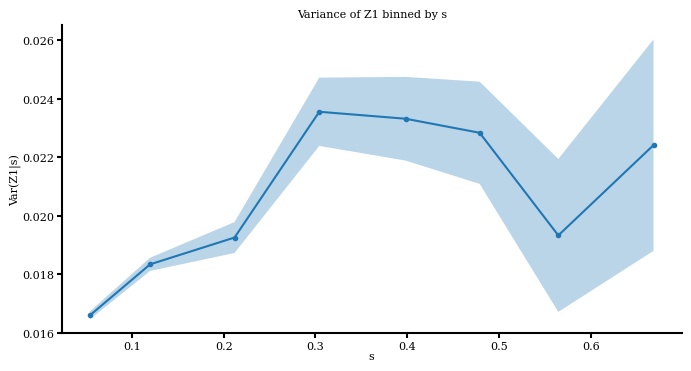

In [144]:
bins = np.linspace(0, 0.8, 10)
plot_grouped_statistics(s_means_z1, var_values_z1, 'Variance of Z1 binned by s', 'Var(Z1|s)', bins)

/tmp/ipykernel_288920/912837614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(


,s_center,mean_values,stdev_values,count
s_bin,,,,
"(0.0, 0.0889]",0.054306,0.02211,0.000271,3583
"(0.0889, 0.178]",0.119911,0.024001,0.000383,2071
"(0.178, 0.267]",0.211855,0.027886,0.001148,448
"(0.267, 0.356]",0.304115,0.02688,0.001363,216
"(0.356, 0.444]",0.398107,0.024209,0.001983,138
"(0.444, 0.533]",0.478795,0.021253,0.001525,82
"(0.533, 0.622]",0.564472,0.018253,0.002703,14
"(0.622, 0.711]",0.668151,0.020718,0.004702,3


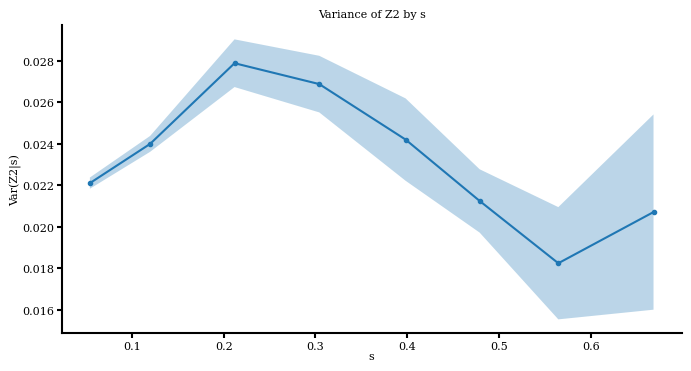

In [145]:
plot_grouped_statistics(s_means_z1, var_values_z2, 'Variance of Z2 by s', 'Var(Z2|s)', bins)

/tmp/ipykernel_288920/912837614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(


,s_center,mean_values,stdev_values,count
s_bin,,,,
"(0.0, 0.0889]",0.054306,0.070832,0.001357,4500
"(0.0889, 0.178]",0.119911,0.102869,0.002385,2849
"(0.178, 0.267]",0.211855,0.126883,0.006867,622
"(0.267, 0.356]",0.304115,0.114956,0.012930,254
"(0.356, 0.444]",0.398107,0.067514,0.012249,156
"(0.444, 0.533]",0.478795,0.056224,0.015694,98
"(0.533, 0.622]",0.564472,0.025647,0.003539,14
"(0.622, 0.711]",0.668151,0.02286,0.006474,3


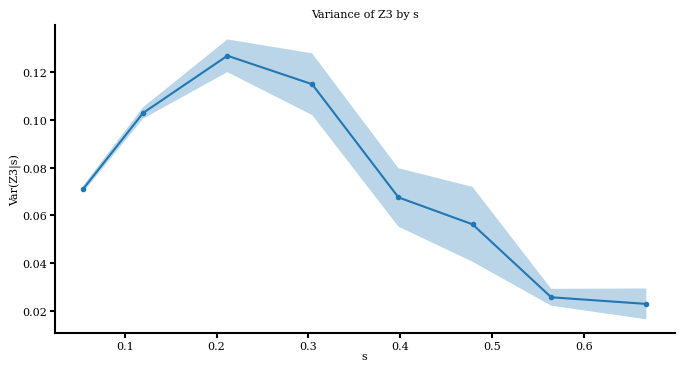

In [146]:
plot_grouped_statistics(s_means_z1, var_values_z3, 'Variance of Z3 by s', 'Var(Z3|s)', bins)

### Compute sliding window statistics for principal components of neural activity in the data

In [119]:
import scipy as sp 
from scipy.stats import pearsonr

t_start = 0
t_end = len(neuromod_activity)

x, neuromod = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size']) 

# s = (neuromod - neuromod.mean()) / neuromod.std()
s = (neuromod - s_train.min()) / (s_train.max() - s_train.min())
U, _, Vt = sp.sparse.linalg.svds(x, k=3)
# print(U.shape, Vt.shape)

x_pc1 = U[:, 0] @ x
x_pc2 = U[:, 1] @ x
x_pc3 = U[:, 2] @ x

U_model, _, Vt_model = sp.sparse.linalg.svds(trajs.detach().numpy())

x_model_pc1 = U[:, 0] @ trajs.detach().numpy()
# x_pc1 = x @ Vt.T[:, 0]
# x_pc2 = x @ Vt.T[:, 1]
# x_pc3 = x @ Vt.T[:, 2]


/tmp/ipykernel_288920/1951078783.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_bin = pearsonr(s_bin, seq[j_start:j_end])[0]


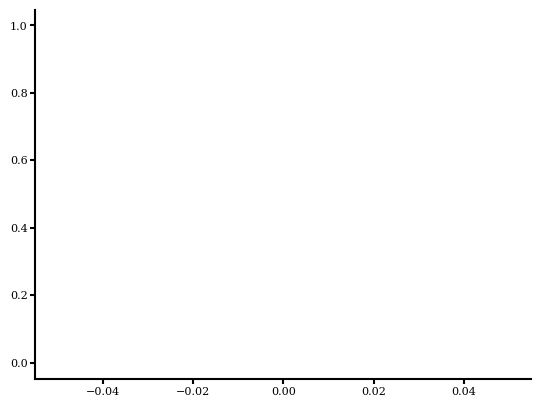

In [121]:
cor_values_pc1, var_values_pc1, s_means_pc1, best_lags_pc1 = sliding_window_correlation(x_pc1, s.flatten())


/tmp/ipykernel_288920/912837614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(


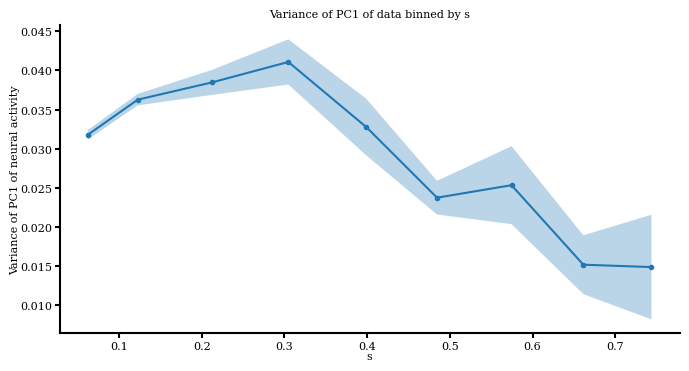

In [123]:
grouped = plot_grouped_statistics(s_means_pc1, var_values_pc1, 'Variance of PC1 of data binned by s', 'Variance of PC1 of neural activity', bins, filename=None)

/tmp/ipykernel_3239754/3344602378.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(


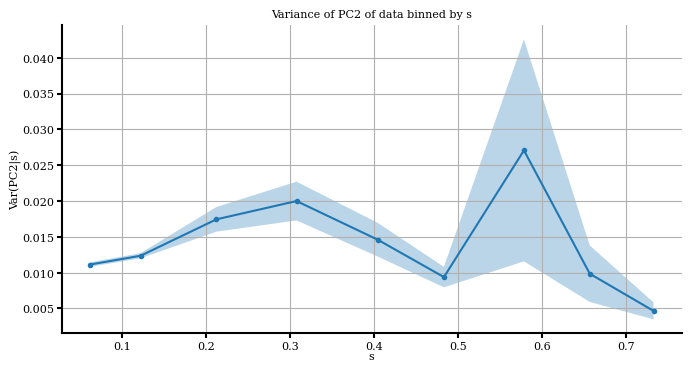

In [18]:
plot_grouped_statistics(s_means_pc1, var_values_pc2, 'Variance of PC2 of data binned by s', 'Var(PC2|s)', bins)

/tmp/ipykernel_3239754/3344602378.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(


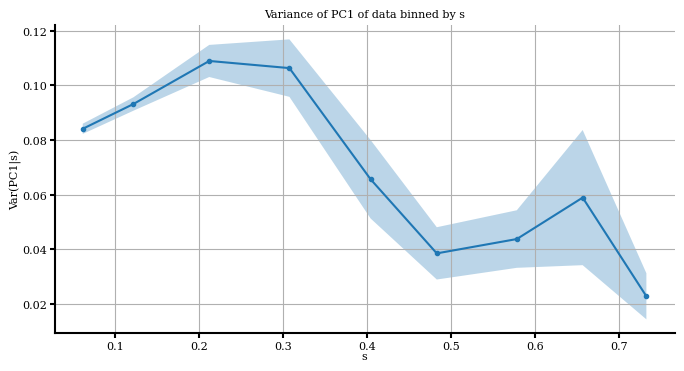

In [19]:
# bins = np.linspace(0,0.7,10)
plot_grouped_statistics(s_means_pc1, var_values_pc3, 'Variance of PC1 of data binned by s', 'Var(PC1|s)', bins)

In [130]:
# align latent and s
Z = Z[:, 10:].T.numpy()
s = s[:-10]
trajs = trajs[:, 10:].T.numpy()
x = x[:, 10:].T

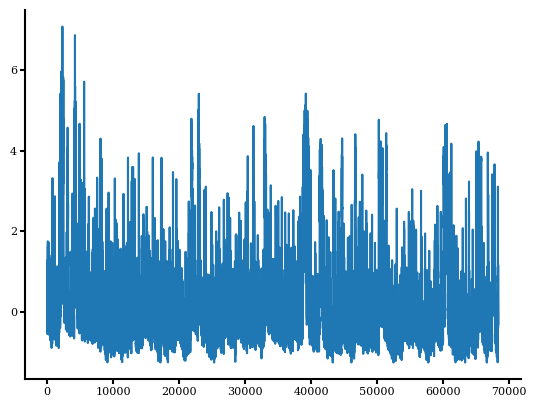

In [139]:
plt.plot(s)

In [ ]:
import numpy as np
from scipy.linalg import svd
import matplotlib.pyplot as plt

def null_potent(Z, s):
    T = Z.shape[0]
    C = np.cov(Z, rowvar=False)

    E, L, _ = svd(C)
    W_zca = E @ np.diag(1/np.sqrt(L)) @ E.T
    # Z_zca = (Z - Z.mean(axis=0)) @ W_zca
    Z_zca = Z @ W_zca
    #Potent via CCA
    # Zc = Z_zca - Z_zca.mean(axis=0)
    # sc = s - s.mean()

    U_z, S_z, Vt_z = svd(Z_zca, full_matrices=False)
    u = Vt_z[0, :] 
    n = Vt_z[1:, :].T 
    Z_potent = Z_zca @ u
    Z_null = Z_zca @ n
    # Sigma_ZZ = (Z_zca.T @ Z_zca) / (T - 1)
    # Sigma_Zs = (Z_zca.T @ s[:, None]) / (T - 1)
    # M = np.linalg.inv(Sigma_ZZ) @ (Sigma_Zs @ Sigma_Zs.T)
    # eigvals, eigvecs = np.linalg.eig(M)
    # u = eigvecs[:, np.argmax(eigvals)]
    # u /= np.linalg.norm(u)
    # n = np.array([-u[1], u[0]])
    #Null-fraction

    # C = np.cov(Z, rowvar=False)
    # Uc, Sc, _ = np.linalg.svd(C)
    # W = Uc @ np.diag(1/np.sqrt(Sc)) @ Uc.T
    # Zw = Z @ W 

    # p = np.linalg.lstsq(Zw, s, rcond=None)[0]
    
    # # P_mat = p.reshape(2, 1)
    # U, S, Vt = svd(P_mat, full_matrices=True)
    # u = U[:, 0]
    # n = U[:, 1]
    return Z_potent, Z_null

In [20]:
Z.shape

torch.Size([2, 23100])

In [ ]:
Z_potent, Z_null = null_potent(Z, s)

In [133]:
def zca_whiten(Zc, eps=1e-10):
    C = np.cov(Zc, rowvar=False)                    
    L, E = np.linalg.eigh(C)                        
    L = np.clip(L, eps, None)
    W = E @ np.diag(1.0 / np.sqrt(L)) @ E.T         
    Z_w = Zc @ W
    return Z_w, W

def potent_null(Z, s):
    Z_w, W = zca_whiten(Z)
    s = s.reshape(-1, 1)
    s_c = s - s.mean(0, keepdims=False)             
    # s_std = s_c / s_c.std(ddof=1)                  

    c = (Z_w.T @ s_c)[:, 0] / (Z_w.shape[0] - 1)  
    if np.allclose(c, 0):
        u = np.array([1.0, 0.0, 0.0])
    else:
        u = c / np.linalg.norm(c)                   

    Z_potent = (Z_w @ u)                            

    Q, _ = np.linalg.qr(u[:, None], mode='complete')  
    N = Q[:, 1:]                                      
    Z_null = Z_w @ N                                  

    w_potent_orig = W @ u         
    N_orig = W @ N                

    return Z_potent, Z_null, u, N, w_potent_orig, N_orig

Z_potent, Z_null, _, _, _, _ = potent_null(Z, s)

In [134]:
x_pcs = np.vstack([x_pc1.reshape(1, -1), x_pc2.reshape(1, -1)]).T
x_potent, x_null, _, _, _, _ = potent_null(x_pcs, s)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 68370 is different from 157380)

In [137]:
np.corrcoef(Z_null[:, 0], Z_potent)[0,1], np.corrcoef(s, Z_null[:, 0])[0,1], np.corrcoef(s, Z_potent)[0,1]

(-4.837830646876901e-16, -3.512528094243198e-17, 0.7645606384177125)

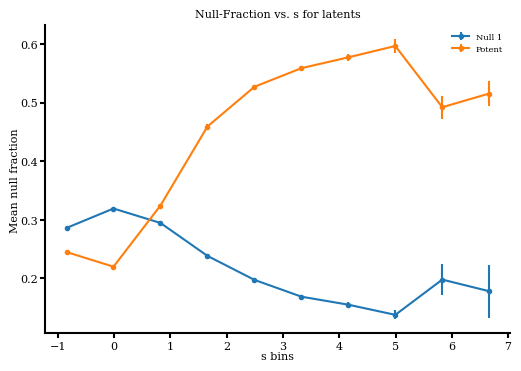

In [138]:
from scipy.stats import binned_statistic
K = 7

total_mag = np.abs(Z_null).sum(axis=1)+ np.abs(Z_potent) 

null_frac_1 = np.abs(Z_null[:, 0]) / total_mag
# null_frac_2 = np.abs(Z_null[:, 1])   / total_mag 
potent_frac = np.abs(Z_potent) / total_mag 
# print(null_frac.shape)
# Compute binned mean, std, and count
bins = 10
bin_means, edges, _ = binned_statistic(s, null_frac_1, statistic='mean', bins=bins)
bin_stds, _, _  = binned_statistic(s, null_frac_1, statistic='std',  bins=bins)
bin_counts, _, _ = binned_statistic(s, null_frac_1, statistic='count', bins=bins)


# bin_means_null_2, edges, _ = binned_statistic(s, null_frac_2, statistic='mean', bins=bins)
# bin_stds_null_2, _, _  = binned_statistic(s, null_frac_2, statistic='std',  bins=bins)
# bin_counts_null_2, _, _ = binned_statistic(s, null_frac_2, statistic='count', bins=bins)


bin_means_potent, _, _ = binned_statistic(s, potent_frac, statistic='mean', bins=bins)
bin_stds_potent, _, _  = binned_statistic(s, potent_frac, statistic='std',  bins=bins)
bin_counts_potent, _, _ = binned_statistic(s, potent_frac, statistic='count', bins=bins)


bin_se = bin_stds / np.sqrt(bin_counts)
bin_se_potent = bin_stds_potent / np.sqrt(bin_counts) 
# Bin centers
centers = 0.5 * (edges[:-1] + edges[1:])

# Plot mean with standard error bars
plt.figure(figsize=(6, 4))
plt.errorbar(centers, bin_means, yerr=bin_se, marker='o', linestyle='-', label='Null 1')
# plt.errorbar(centers, bin_means_null_2, yerr=bin_se, marker='o', linestyle='-', label='Null 2')
plt.errorbar(centers, bin_means_potent, yerr=bin_se_potent, marker='o', linestyle='-', label='Potent')

plt.xlabel('s bins')
plt.ylabel('Mean null fraction')
plt.title('Null-Fraction vs. s for latents')
# plt.ylim(0, 0.4)
plt.legend()
plt.show()

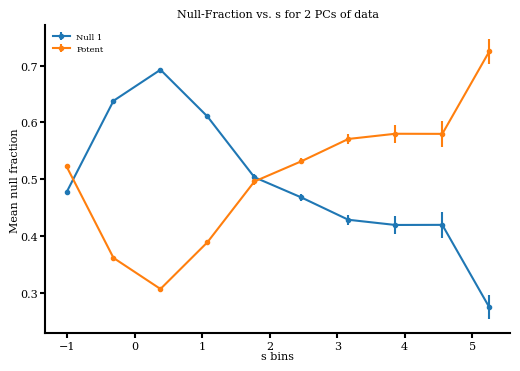

In [ ]:
from scipy.stats import binned_statistic
K = 7

total_mag = np.abs(x_null).sum(axis=1)+ np.abs(x_potent) 

null_frac_1 = np.abs(x_null[:, 0]) / total_mag
# null_frac_2 = np.abs(Z_null[:, 1])   / total_mag 
potent_frac = np.abs(x_potent) / total_mag 
# print(null_frac.shape)
# Compute binned mean, std, and count
bins = 10
bin_means, edges, _ = binned_statistic(s, null_frac_1, statistic='mean', bins=bins)
bin_stds, _, _  = binned_statistic(s, null_frac_1, statistic='std',  bins=bins)
bin_counts, _, _ = binned_statistic(s, null_frac_1, statistic='count', bins=bins)


# bin_means_null_2, edges, _ = binned_statistic(s, null_frac_2, statistic='mean', bins=bins)
# bin_stds_null_2, _, _  = binned_statistic(s, null_frac_2, statistic='std',  bins=bins)
# bin_counts_null_2, _, _ = binned_statistic(s, null_frac_2, statistic='count', bins=bins)


bin_means_potent, _, _ = binned_statistic(s, potent_frac, statistic='mean', bins=bins)
bin_stds_potent, _, _  = binned_statistic(s, potent_frac, statistic='std',  bins=bins)
bin_counts_potent, _, _ = binned_statistic(s, potent_frac, statistic='count', bins=bins)


bin_se = bin_stds / np.sqrt(bin_counts)
bin_se_potent = bin_stds_potent / np.sqrt(bin_counts) 
# Bin centers
centers = 0.5 * (edges[:-1] + edges[1:])

# Plot mean with standard error bars
plt.figure(figsize=(6, 4))
plt.errorbar(centers, bin_means, yerr=bin_se, marker='o', linestyle='-', label='Null 1')
# plt.errorbar(centers, bin_means_null_2, yerr=bin_se, marker='o', linestyle='-', label='Null 2')
plt.errorbar(centers, bin_means_potent, yerr=bin_se_potent, marker='o', linestyle='-', label='Potent')

plt.xlabel('s bins')
plt.ylabel('Mean null fraction')
plt.title('Null-Fraction vs. s for 2 PCs of data')
# plt.ylim(0, 0.4)
plt.legend()
plt.show()

### Do a shuffled control

In [32]:
def shuffle_bins(s, b: int, seed: int | None = None):
    """
    Shuffle non-overlapping bins of length b in a 1D signal.
    - s: 1D sequence or numpy array
    - b: bin size (>0)
    - seed: optional int for reproducibility

    Returns the signal with full bins randomly permuted.
    Trailing elements (len(s) % b) stay in place.
    """
    if b <= 0:
        raise ValueError("b must be a positive integer")

    n = len(s)
    n_bins = n // b

    full = s[: n_bins * b].reshape(n_bins, b)
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_bins)
    shuffled_full = full[order].reshape(-1)

    out = np.concatenate([shuffled_full, s[n_bins * b :]])
    return out 

In [ ]:
shuffle_bin_width = 10
s_shuffled = shuffle_bins(s, shuffle_bin_width)
plt.plot(s_shuffled)

In [ ]:
Z_potent, Z_null, _, _, _, _ = potent_null(Z, s_shuffled)

In [ ]:
np.corrcoef(Z_null[:, 0], Z_potent)[0,1], np.corrcoef(s, Z_null[:, 0])[0,1], np.corrcoef(s_shuffled, Z_potent)[0,1]

In [ ]:
from scipy.stats import binned_statistic
K = 7

total_mag = np.abs(Z_null).sum(axis=1)+ np.abs(Z_potent) 

null_frac_1 = np.abs(Z_null[:, 0]) / total_mag
null_frac_2 = np.abs(Z_null[:, 1]) / total_mag 
potent_frac = np.abs(Z_potent) / total_mag 
# print(null_frac.shape)
# Compute binned mean, std, and count
bins = 10
bin_means, edges, _ = binned_statistic(s_shuffled, null_frac_1, statistic='mean', bins=bins)
bin_stds, _, _  = binned_statistic(s_shuffled, null_frac_1, statistic='std',  bins=bins)
bin_counts, _, _ = binned_statistic(s_shuffled, null_frac_1, statistic='count', bins=bins)


bin_means_null_2, edges, _ = binned_statistic(s_shuffled, null_frac_2, statistic='mean', bins=bins)
bin_stds_null_2, _, _  = binned_statistic(s_shuffled, null_frac_2, statistic='std',  bins=bins)
bin_counts_null_2, _, _ = binned_statistic(s_shuffled, null_frac_2, statistic='count', bins=bins)


bin_means_potent, _, _ = binned_statistic(s_shuffled, potent_frac, statistic='mean', bins=bins)
bin_stds_potent, _, _  = binned_statistic(s_shuffled, potent_frac, statistic='std',  bins=bins)
bin_counts_potent, _, _ = binned_statistic(s_shuffled, potent_frac, statistic='count', bins=bins)


bin_se = bin_stds / np.sqrt(bin_counts)
bin_se_potent = bin_stds_potent / np.sqrt(bin_counts) 
# Bin centers
centers = 0.5 * (edges[:-1] + edges[1:])

# Plot mean with standard error bars
plt.figure(figsize=(6, 4))
plt.errorbar(centers, bin_means, yerr=bin_se, marker='o', linestyle='-', label='Null 1')
plt.errorbar(centers, bin_means_null_2, yerr=bin_se, marker='o', linestyle='-', label='Null 2')
plt.errorbar(centers, bin_means_potent, yerr=bin_se_potent, marker='o', linestyle='-', label='Potent')

plt.xlabel('s bins')
plt.ylabel('Mean null fraction')
plt.title('Null-Fraction vs. s shuffled control')
# plt.ylim(0, 0.4)
plt.legend()
plt.show()